# Module 07-02 · Multi-Head Attention **From Scratch**

**미니 목표**: Q/K/V 행렬을 직접 손으로 만들고,  
head 쪼개기 → 병렬 attention → concat → W_O 까지 한 줄씩 추적한다.

$$\text{MHA}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W^O$$
$$\text{head}_i = \text{Attention}(X W^Q_i,\; X W^K_i,\; X W^V_i)$$
$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

In [2]:
from tool2 import *
device = 'mps'  # cpu, cuda 
torch.manual_seed(42)

In [4]:
B = 1  # Batch
N = 6  # Sequence Length
d_model = 8  # Embedding Size (Token dimension) 
h = 2  # Header Size

In [10]:
X = torch.rand(B, N, d_model)
print('X:', X.shape)

scale = math.sqrt(2.0 / d_model + d_model)  # Xavier Initialization
Wq = torch.randn(d_model, d_model)  * scale 
Wk = torch.randn(d_model, d_model)  * scale 
Wv = torch.randn(d_model, d_model)  * scale 
Wo = torch.randn(d_model, d_model)  * scale 

print('Wq:', Wq.shape)

X: torch.Size([1, 6, 8])
Wq: torch.Size([8, 8])


## Step 2 · 전체 Q, K, V 투영

`X @ Wq` 한 번으로 모든 head 의 Q 를 동시에 만든다.  
아직은 head 로 쪼개지 않은 상태 — shape 은 여전히 `(B, N, d_model)`.

In [11]:
Q_full = X @ Wq   # (B, N - sequence length, d_model)
K_full = X @ Wk
V_full = X @ Wv

print('Q_full:', Q_full.shape)

Q_full: torch.Size([1, 6, 8])


## Step 3 · Head 로 쪼개기 ← **핵심 트릭**

```
(B, N, d_model)
  → view(B, N, h, d_k)     # d_model 을 h 조각으로 분할
  → transpose(1, 2)         # head 축을 앞으로
  → (B, h, N, d_k)          # ← 이 shape 으로 병렬 연산
```

head 가 따로 새로운 행렬을 갖는 게 아니라,  
하나의 큰 투영 행렬을 **그냥 잘라서** 각 head 에 배당한다.

In [15]:
def split_heads(x, h, d_k):
    B, N, _ = x.shape
    return x.view(B, N, h, d_k).transpose(1, 2)  # (B, h, N, d_k)
d_k = d_model // h

Q = split_heads(Q_full, h, d_k)
K = split_heads(K_full, h, d_k)
V = split_heads(V_full, h, d_k)

print('Q:', Q.shape)   # # (1, 2, 6, 4)  ← (B, h, N, d_k)
# batch 첫번째, 첫번째 header 데이터 보기
# batch 첫번째, 두번째 header 데이터 보기
print("head-0 Q[0]:\n", Q[0, 0].round(decimals=3))
print("head-1 Q[0]:\n", Q[0, 1].round(decimals=3))

Q: torch.Size([1, 2, 6, 4])
head-0 Q[0]:
 tensor([[  2.0180,  -4.5270,   2.8180,   5.2710],
        [ -3.6110, -10.2300,   2.7400,   5.4150],
        [  5.9740, -10.0330,   5.9400,   8.2960],
        [  4.8560,  -8.1800,   4.2180,   4.9460],
        [  1.2870,  -6.2400,   1.3790,   5.1060],
        [  2.3280, -13.2540,   5.9220,   6.7180]])
head-1 Q[0]:
 tensor([[ -2.6660,  -3.0270,  -4.6920,   5.5700],
        [  2.5530,  -3.3070,  -5.1310,   2.3170],
        [ -4.5790,  -9.7980,  -7.7370,   3.6320],
        [ -7.4980,  -3.8020, -10.5480,   4.1930],
        [ -6.2390,  -4.2310,  -8.4190,   5.7940],
        [ -2.6950,  -5.4420, -11.9750,   3.3890]])


## Step 4 · 각 Head 에서 Scaled Dot-Product Attention

`(B, h, N, d_k) @ (B, h, d_k, N)` → `(B, h, N, N)` — h 개의 attention 행렬이 **한 번의 bmm** 으로.

In [21]:
scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
print(scores.shape)

A = scores.softmax(dim=-1)
print(A[0, 0].round(decimals=3))

head_out = A @ V
print('head_out:', head_out.shape)

torch.Size([1, 2, 6, 6])
tensor([[0.0000, 0.3290, 0.0000, 0.0300, 0.0000, 0.6400],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0470, 0.0000, 0.0010, 0.0000, 0.9520],
        [0.0000, 0.2200, 0.0000, 0.0030, 0.0000, 0.7770],
        [0.0000, 0.9970, 0.0000, 0.0010, 0.0000, 0.0020],
        [0.0000, 0.9990, 0.0000, 0.0000, 0.0000, 0.0010]])
head_out: torch.Size([1, 2, 6, 4])


## Step 5 · Concat + W_O 투영

```
(B, h, N, d_k)
  → transpose(1,2) → (B, N, h, d_k)
  → contiguous().view(B, N, d_model)   # concat
  → @ Wo                               # 최종 투영
  → (B, N, d_model)                    # 입력과 동일한 shape!
```

In [27]:
concat = (head_out.transpose(1, 2)
    .contiguous()
    .view(B, N, d_model))
print('concat:', concat.shape)
output = concat @ Wo
print('output:', output.shape)
print('X    :', X.shape)

concat: torch.Size([1, 6, 8])
output: torch.Size([1, 6, 8])
X    : torch.Size([1, 6, 8])


/var/folders/r_/d9877jzs33s401wd0w2ntr400000gn/T/ipykernel_45825/3492500371.py:20: UserWarning: Glyph 44057 (\N{HANGUL SYLLABLE GAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/r_/d9877jzs33s401wd0w2ntr400000gn/T/ipykernel_45825/3492500371.py:20: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/r_/d9877jzs33s401wd0w2ntr400000gn/T/ipykernel_45825/3492500371.py:20: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/r_/d9877jzs33s401wd0w2ntr400000gn/T/ipykernel_45825/3492500371.py:20: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/r_/d9877jzs33s401wd0w2ntr400000gn/T/ipykernel_45825/3492500371.py:20: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.sh

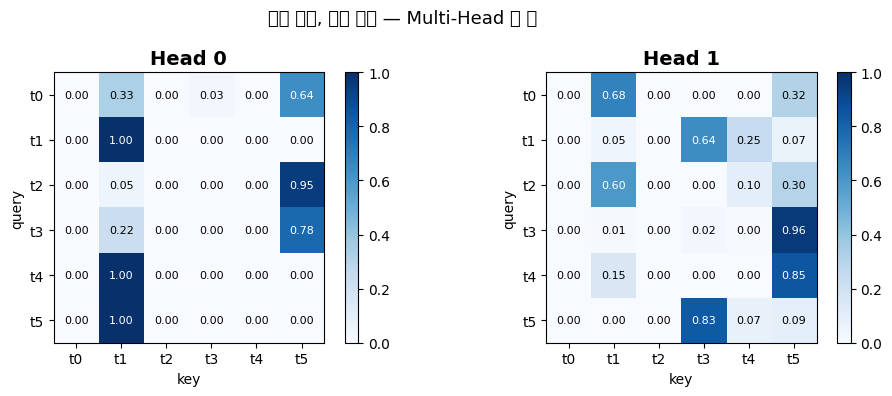

In [28]:
fig, axes = plt.subplots(1, h, figsize=(5 * h, 4))
token_labels = [f"t{i}" for i in range(N)]

for hi in range(h):
    ax = axes[hi]
    attn = A[0, hi].detach().numpy()   # (N, N)
    im = ax.imshow(attn, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"Head {hi}", fontsize=14, fontweight="bold")
    ax.set_xticks(range(N)); ax.set_xticklabels(token_labels)
    ax.set_yticks(range(N)); ax.set_yticklabels(token_labels)
    ax.set_xlabel("key"); ax.set_ylabel("query")
    for i in range(N):
        for j in range(N):
            ax.text(j, i, f"{attn[i,j]:.2f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if attn[i,j] > 0.5 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("같은 입력, 다른 시선 — Multi-Head 의 힘", fontsize=13)
plt.tight_layout(); plt.show()